**Handwritten Digit Classification using Deep learning**

Importing all the dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from fastai.metrics import accuracy
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the MNIST dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print(type(X_train))

<class 'numpy.ndarray'>


In [4]:
# shape
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [5]:
# Printing the 1st image.
print(X_train[0])
print(X_train[0].shape)
print(y_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

Label for it: 5


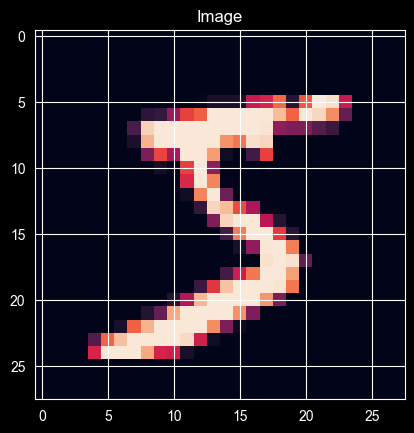

In [6]:
#Displaying the 1st Image.
plt.imshow(X_train[0])
plt.title('Image')
print('Label for it:',y_train[0])

In [7]:
# All the unique values in Y_train and Y_test
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [8]:
#Normalization
#Scaling the values
X_train = X_train/255
X_test = X_test/255

Building the Neural Network

**MODEL 1**

In [9]:
# Setting up layers.
model1 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

C:\Users\Kangan Mane\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# compiling the Model.
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
#Trainning
m1 = model1.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9289 - loss: 0.2436
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9688 - loss: 0.1043
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9783 - loss: 0.0718
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9839 - loss: 0.0528
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9874 - loss: 0.0394
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9896 - loss: 0.0329
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9905 - loss: 0.0290
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9925 - loss: 0.0219
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9928 - loss: 0.0206
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9935 - loss: 0.0187


Training Accuracy is : 99.35%

**MODEL 2**

In [12]:
# Model 2 with Dropout
model2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),  # NEW - Drop 20% neurons
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dropout(0.2),  # NEW - Drop 20% neurons
    keras.layers.Dense(10, activation='sigmoid')
])

In [13]:
# compiling Model 2
model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
#Training Model 2
m2 = model2.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8966 - loss: 0.3469
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9499 - loss: 0.1707
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9612 - loss: 0.1312
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9664 - loss: 0.1099
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9715 - loss: 0.0939
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9732 - loss: 0.0872
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9738 - loss: 0.0800
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9757 - loss: 0.0757
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9768 - loss: 0.0671
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9760 - loss: 0.0683


Model 2 training accuracy : 97.60%

**Model Evaluation**

Calculating accuracy on Test Data

In [15]:
# Evaluating Model 1
loss_m1, accuracy_m1 = model1.evaluate(X_test, y_test)
print("Model 1 - Test Accuracy:", accuracy_m1*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - accuracy: 0.9671 - loss: 0.1531
Model 1 - Test Accuracy: 96.71000242233276


In [16]:
# Evaluating Model 2
loss_m2, accuracy_m2 = model2.evaluate(X_test, y_test)
print("Model 2 - Test Accuracy:", accuracy_m2*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9768 - loss: 0.0774
Model 2 - Test Accuracy: 97.680002450943


**VISUALIZATION**

Actual Label: 7


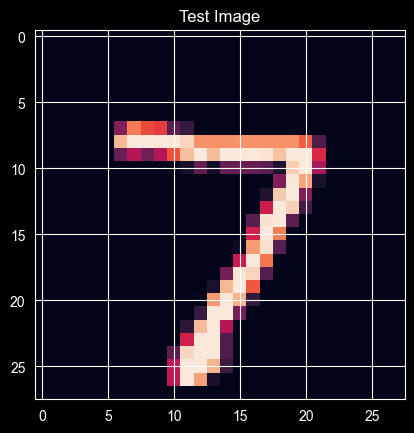

In [17]:
#Checking on 1st Test Image.
plt.imshow(X_test[0])
plt.title('Test Image')
print('Actual Label:',y_test[0])

In [18]:
# Get predictions for first image
pred_m1 = np.argmax(model1.predict(X_test)[0])
pred_m2 = np.argmax(model2.predict(X_test)[0])

print(f"Model 1 Prediction: {pred_m1}")
print(f"Model 2 Prediction: {pred_m2}")
print(f"Actual Label: {y_test[0]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step
Model 1 Prediction: 7
Model 2 Prediction: 7
Actual Label: 7


**Comparing Training Curves**

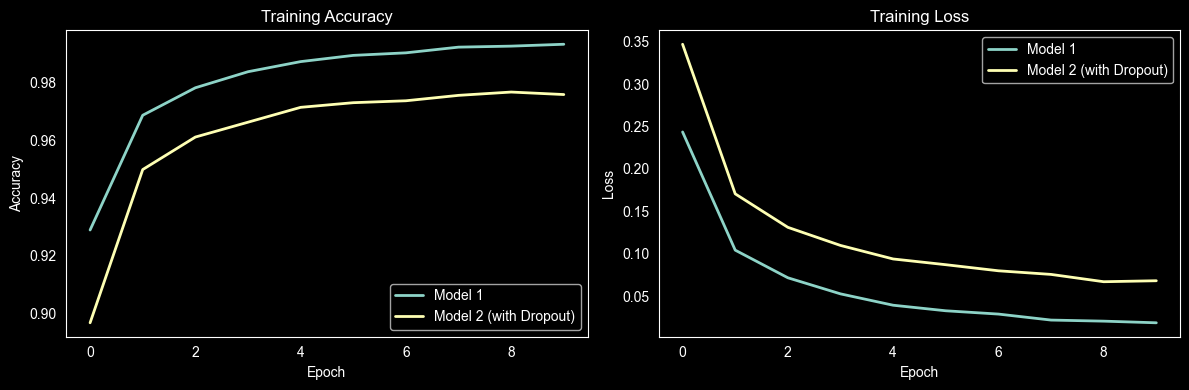

In [21]:
# Plot training accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(m1.history['accuracy'], label='Model 1', linewidth=2)
plt.plot(m2.history['accuracy'], label='Model 2 (with Dropout)', linewidth=2)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(m1.history['loss'], label='Model 1', linewidth=2)
plt.plot(m2.history['loss'], label='Model 2 (with Dropout)', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Predictions on Test Set**

In [22]:
# Get all predictions
my_prediction_m1 = model1.predict(X_test)
my_prediction_m2 = model2.predict(X_test)

# Convert to class labels
pred_labels_m1 = np.argmax(my_prediction_m1, axis=1)
pred_labels_m2 = np.argmax(my_prediction_m2, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step


**Compare Predictions - Sample Images**

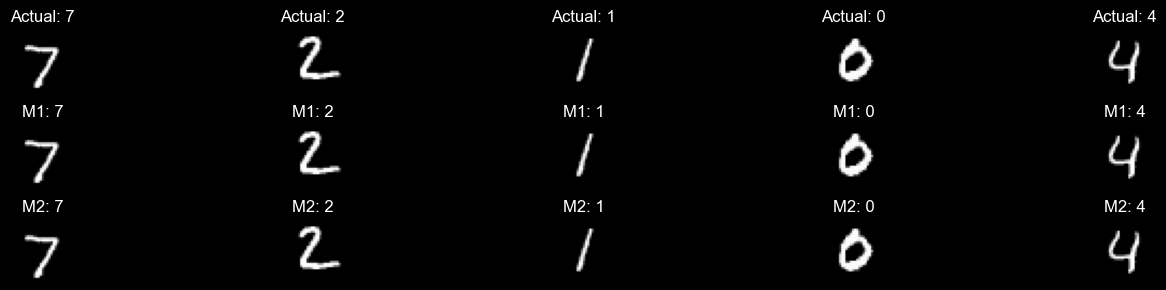

In [23]:
# Show predictions on 5 test images
fig = plt.figure(figsize=(15, 3))

for i in range(5):
    # Actual image
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'Actual: {y_test[i]}')
    plt.axis('off')
    
    # Model 1 prediction
    plt.subplot(3, 5, i+6)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'M1: {pred_labels_m1[i]}')
    plt.axis('off')
    
    # Model 2 prediction
    plt.subplot(3, 5, i+11)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'M2: {pred_labels_m2[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**Model Comparison**

In [28]:
print("MODEL COMPARISON")
print(f"Model 1O riginal - Accuracy: {accuracy_m1*100:.2f}%")
print(f"Model 2 with Dropout  - Accuracy: {accuracy_m2*100:.2f}%")
if accuracy_m2 > accuracy_m1:
    print(f"Model 2 is better by {(accuracy_m2-accuracy_m1)*100:.2f}%")
else:
    print(f"Model 1 is better by {(accuracy_m1-accuracy_m2)*100:.2f}%")

MODEL COMPARISON
Model 1O riginal - Accuracy: 96.71%
Model 2 with Dropout  - Accuracy: 97.68%
Model 2 is better by 0.97%
